# Spatial Hash vs Naive Benchmark Analysis

This notebook analyzes the performance of the Spatial Hash implementation versus the Naive approach for neighbor queries in the predator-prey simulation.

**Benchmark Configuration:**
- World sizes: 600, 1200, 2000, 4000
- Entity counts (each): 10, 50, 100, 500, 1000, 2000, 4000
- Phases: pred_sense (build, query, total), prey_sense (build, query, total)
- Multiple iterations per configuration for statistical analysis

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os
import warnings
warnings.filterwarnings('ignore')

# Configuration
CSV_FILE = 'benchmark_results.csv'
OUTPUT_DIR = 'plots'

if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

# Set style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

In [4]:
# Load and Preprocess Data
df = pd.read_csv(CSV_FILE)

# Calculate derived metrics
df['total_entities'] = df['num_preds'] + df['num_preys']
df['density'] = df['total_entities'] / (df['world_size'] ** 2)

# Extract phase type (pred_sense or prey_sense) and operation (build, query, total)
df['sense_type'] = df['phase'].apply(lambda x: 'predator' if x.startswith('pred') else 'prey')
df['operation'] = df['phase'].apply(lambda x: x.split('_')[-1])

print(f"Loaded {len(df)} rows")
print(f"\nWorld sizes: {sorted(df['world_size'].unique())}")
print(f"Entity counts (each): {sorted(df['num_preds'].unique())}")
print(f"Phases: {df['phase'].unique()}")
print(f"Iterations per config: {df.groupby(['world_size', 'num_preds', 'phase'])['iteration'].count().mean():.0f}")

df.head(10)

Loaded 48849 rows

World sizes: [np.int64(600), np.int64(1200), np.int64(2000), np.int64(4000)]
Entity counts (each): [np.int64(10), np.int64(50), np.int64(100), np.int64(500), np.int64(1000), np.int64(2000), np.int64(4000)]
Phases: <StringArray>
['pred_sense_build', 'pred_sense_query', 'pred_sense_total',
 'prey_sense_build', 'prey_sense_query', 'prey_sense_total']
Length: 6, dtype: str
Iterations per config: 291


,phase,world_size,num_preds,num_preys,iteration,seed,cell_size,density_preds,density_preys,neighbors_pred_sh,neighbors_pred_naive,neighbors_prey_sh,neighbors_prey_naive,sh_ms,naive_ms,speedup,total_entities,density,sense_type,operation
0,pred_sense_build,600,10,10,0,42,200,0.000028,0.000028,10,0,0,0,0.003,0.000,0.00,20,0.000056,predator,build
1,pred_sense_query,600,10,10,0,42,200,0.000028,0.000028,10,10,0,0,0.017,0.005,0.27,20,0.000056,predator,query
2,pred_sense_total,600,10,10,0,42,200,0.000028,0.000028,10,10,0,0,0.021,0.005,0.23,20,0.000056,predator,total
3,pred_sense_build,600,10,10,1,43,200,0.000028,0.000028,5,0,0,0,0.003,0.000,0.00,20,0.000056,predator,build
4,pred_sense_query,600,10,10,1,43,200,0.000028,0.000028,5,5,0,0,0.011,0.004,0.35,20,0.000056,predator,query
5,pred_sense_total,600,10,10,1,43,200,0.000028,0.000028,5,5,0,0,0.014,0.004,0.27,20,0.000056,predator,total
6,pred_sense_build,600,10,10,2,44,200,0.000028,0.000028,2,0,0,0,0.003,0.000,0.00,20,0.000056,predator,build
7,pred_sense_query,600,10,10,2,44,200,0.000028,0.000028,2,2,0,0,0.011,0.004,0.38,20,0.000056,predator,query
8,pred_sense_total,600,10,10,2,44,200,0.000028,0.000028,2,2,0,0,0.014,0.004,0.29,20,0.000056,predator,total
9,pred_sense_build,600,10,10,3,45,200,0.000028,0.000028,6,0,0,0,0.003,0.000,0.00,20,0.000056,predator,build


## Statistical Summary Table

Computing mean, standard deviation, min, max, and confidence intervals for execution times across all configurations.

In [5]:
# Statistical analysis grouped by configuration
def compute_stats(group):
    """Compute comprehensive statistics for a group."""
    n = len(group)
    
    # Spatial Hash stats
    sh_mean = group['sh_ms'].mean()
    sh_std = group['sh_ms'].std()
    sh_sem = stats.sem(group['sh_ms'])
    sh_ci95 = sh_sem * stats.t.ppf((1 + 0.95) / 2, n - 1) if n > 1 else 0
    
    # Naive stats
    naive_mean = group['naive_ms'].mean()
    naive_std = group['naive_ms'].std()
    naive_sem = stats.sem(group['naive_ms'])
    naive_ci95 = naive_sem * stats.t.ppf((1 + 0.95) / 2, n - 1) if n > 1 else 0
    
    # Speedup stats
    speedup_mean = naive_mean / sh_mean if sh_mean > 0 else 0
    speedup_median = group['speedup'].median()
    
    return pd.Series({
        'n_samples': n,
        'sh_mean_ms': sh_mean,
        'sh_std_ms': sh_std,
        'sh_ci95': sh_ci95,
        'sh_min_ms': group['sh_ms'].min(),
        'sh_max_ms': group['sh_ms'].max(),
        'naive_mean_ms': naive_mean,
        'naive_std_ms': naive_std,
        'naive_ci95': naive_ci95,
        'naive_min_ms': group['naive_ms'].min(),
        'naive_max_ms': group['naive_ms'].max(),
        'speedup_mean': speedup_mean,
        'speedup_median': speedup_median,
        'speedup_std': group['speedup'].std(),
    })

# Filter to 'total' phase for main analysis
df_total = df[df['operation'] == 'total']

# Compute statistics for each configuration
stats_df = df_total.groupby(['world_size', 'total_entities', 'sense_type']).apply(compute_stats).reset_index()

print("Statistical Summary (Total Phase Only):")
print("=" * 80)
display(stats_df.round(4))

Statistical Summary (Total Phase Only):


,world_size,total_entities,sense_type,n_samples,sh_mean_ms,sh_std_ms,sh_ci95,sh_min_ms,sh_max_ms,naive_mean_ms,naive_std_ms,naive_ci95,naive_min_ms,naive_max_ms,speedup_mean,speedup_median,speedup_std
0,600,20,predator,500.0,0.0148,0.0091,0.0008,0.009,0.067,0.0043,0.0027,0.0002,0.002,0.024,0.2895,0.300,0.1002
1,600,20,prey,500.0,0.0144,0.0060,0.0005,0.009,0.054,0.0044,0.0027,0.0002,0.002,0.027,0.3065,0.300,0.1201
2,600,100,predator,500.0,0.2026,0.1363,0.0120,0.094,0.844,0.1443,0.0970,0.0085,0.068,0.594,0.7122,0.710,0.1771
3,600,100,prey,500.0,0.1962,0.1207,0.0106,0.096,0.881,0.1372,0.0825,0.0072,0.067,0.536,0.6994,0.710,0.1606
4,600,200,predator,500.0,0.4966,0.1845,0.0162,0.305,1.523,0.4507,0.1854,0.0163,0.270,1.786,0.9076,0.890,0.1968
5,600,200,prey,500.0,0.5028,0.2105,0.0185,0.309,1.803,0.4384,0.1824,0.0160,0.275,1.606,0.8720,0.880,0.1967
6,600,1000,predator,72.0,10.5585,2.8204,0.6628,7.042,19.483,10.4900,2.5905,0.6087,6.861,17.026,0.9935,1.010,0.2567
7,600,1000,prey,77.0,10.0544,2.5295,0.5741,6.863,17.763,9.8147,1.5945,0.3619,6.930,14.484,0.9762,1.000,0.2289
8,600,2000,predator,25.0,37.3034,5.0394,2.0801,28.311,46.300,42.3490,6.0150,2.4829,33.706,54.689,1.1353,1.140,0.2475
9,600,2000,prey,25.0,38.3688,7.0938,2.9282,28.389,57.092,41.3077,5.0402,2.0805,32.886,52.591,1.0766,1.100,0.2678


## Summary Statistics by Entity Count and World Size

Aggregated view showing when spatial hashing becomes beneficial.

In [6]:
# Create pivot tables for speedup analysis
speedup_pivot = stats_df[stats_df['sense_type'] == 'predator'].pivot(
    index='world_size', 
    columns='total_entities', 
    values='speedup_mean'
)

print("Speedup Factor (Naive / Spatial Hash) - Predator Sensing")
print("Values > 1 mean spatial hash is faster\n")
display(speedup_pivot.round(2))

# Also show execution times comparison
print("\n\nMean Execution Times (ms) - Predator Sensing")
print("-" * 60)

sh_times = stats_df[stats_df['sense_type'] == 'predator'].pivot(
    index='world_size', 
    columns='total_entities', 
    values='sh_mean_ms'
)
print("\nSpatial Hash:")
display(sh_times.round(3))

naive_times = stats_df[stats_df['sense_type'] == 'predator'].pivot(
    index='world_size', 
    columns='total_entities', 
    values='naive_mean_ms'
)
print("\nNaive:")
display(naive_times.round(3))

Speedup Factor (Naive / Spatial Hash) - Predator Sensing
Values > 1 mean spatial hash is faster



Speedup Factor (Naive / Spatial Hash) - Predator Sensing
Values > 1 mean spatial hash is faster



total_entities,20,100,200,1000,2000,4000,8000
world_size,,,,,,,
600,0.29,0.71,0.91,0.99,1.14,1.06,1.10
1200,0.23,0.69,1.09,1.95,2.27,2.25,2.40
2000,0.19,0.67,1.16,3.09,4.20,4.80,5.27
4000,0.17,0.72,1.32,4.91,7.81,12.26,15.03




Mean Execution Times (ms) - Predator Sensing
------------------------------------------------------------

Spatial Hash:


Speedup Factor (Naive / Spatial Hash) - Predator Sensing
Values > 1 mean spatial hash is faster



total_entities,20,100,200,1000,2000,4000,8000
world_size,,,,,,,
600,0.29,0.71,0.91,0.99,1.14,1.06,1.10
1200,0.23,0.69,1.09,1.95,2.27,2.25,2.40
2000,0.19,0.67,1.16,3.09,4.20,4.80,5.27
4000,0.17,0.72,1.32,4.91,7.81,12.26,15.03




Mean Execution Times (ms) - Predator Sensing
------------------------------------------------------------

Spatial Hash:


total_entities,20,100,200,1000,2000,4000,8000
world_size,,,,,,,
600,0.015,0.203,0.497,10.559,37.303,155.122,611.891
1200,0.011,0.078,0.203,2.672,9.637,51.865,205.723
2000,0.017,0.075,0.149,1.816,5.456,16.563,64.986
4000,0.011,0.052,0.113,0.946,2.063,7.082,23.830



Naive:


total_entities,20,100,200,1000,2000,4000,8000
world_size,,,,,,,
600,0.004,0.144,0.451,10.490,42.349,164.994,670.325
1200,0.003,0.054,0.221,5.213,21.892,116.729,494.627
2000,0.003,0.050,0.173,5.615,22.916,79.574,342.174
4000,0.002,0.038,0.149,4.647,16.107,86.798,358.200


## 1. Speedup Heatmap

Visualizing speedup across different World Sizes and Entity Counts. Green indicates spatial hash is faster (speedup > 1).

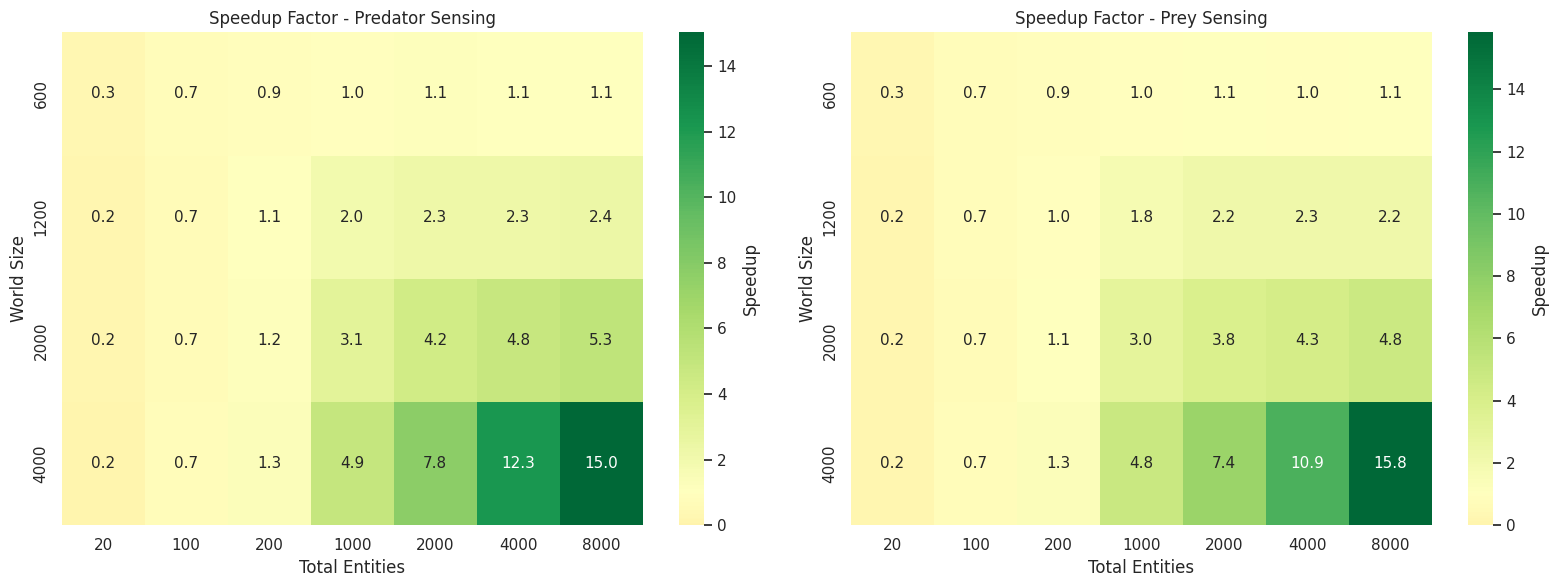

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, sense_type in enumerate(['predator', 'prey']):
    heatmap_data = stats_df[stats_df['sense_type'] == sense_type].pivot(
        index='world_size', 
        columns='total_entities', 
        values='speedup_mean'
    )
    
    ax = axes[idx]
    sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap='RdYlGn', center=1, 
                ax=ax, cbar_kws={'label': 'Speedup'}, vmin=0, vmax=max(heatmap_data.max().max(), 2))
    ax.set_title(f'Speedup Factor - {sense_type.capitalize()} Sensing')
    ax.set_ylabel('World Size')
    ax.set_xlabel('Total Entities')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'speedup_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

## 2. Execution Time Comparison (Log-Log Scale)

Comparing absolute execution times between Spatial Hash and Naive approaches.

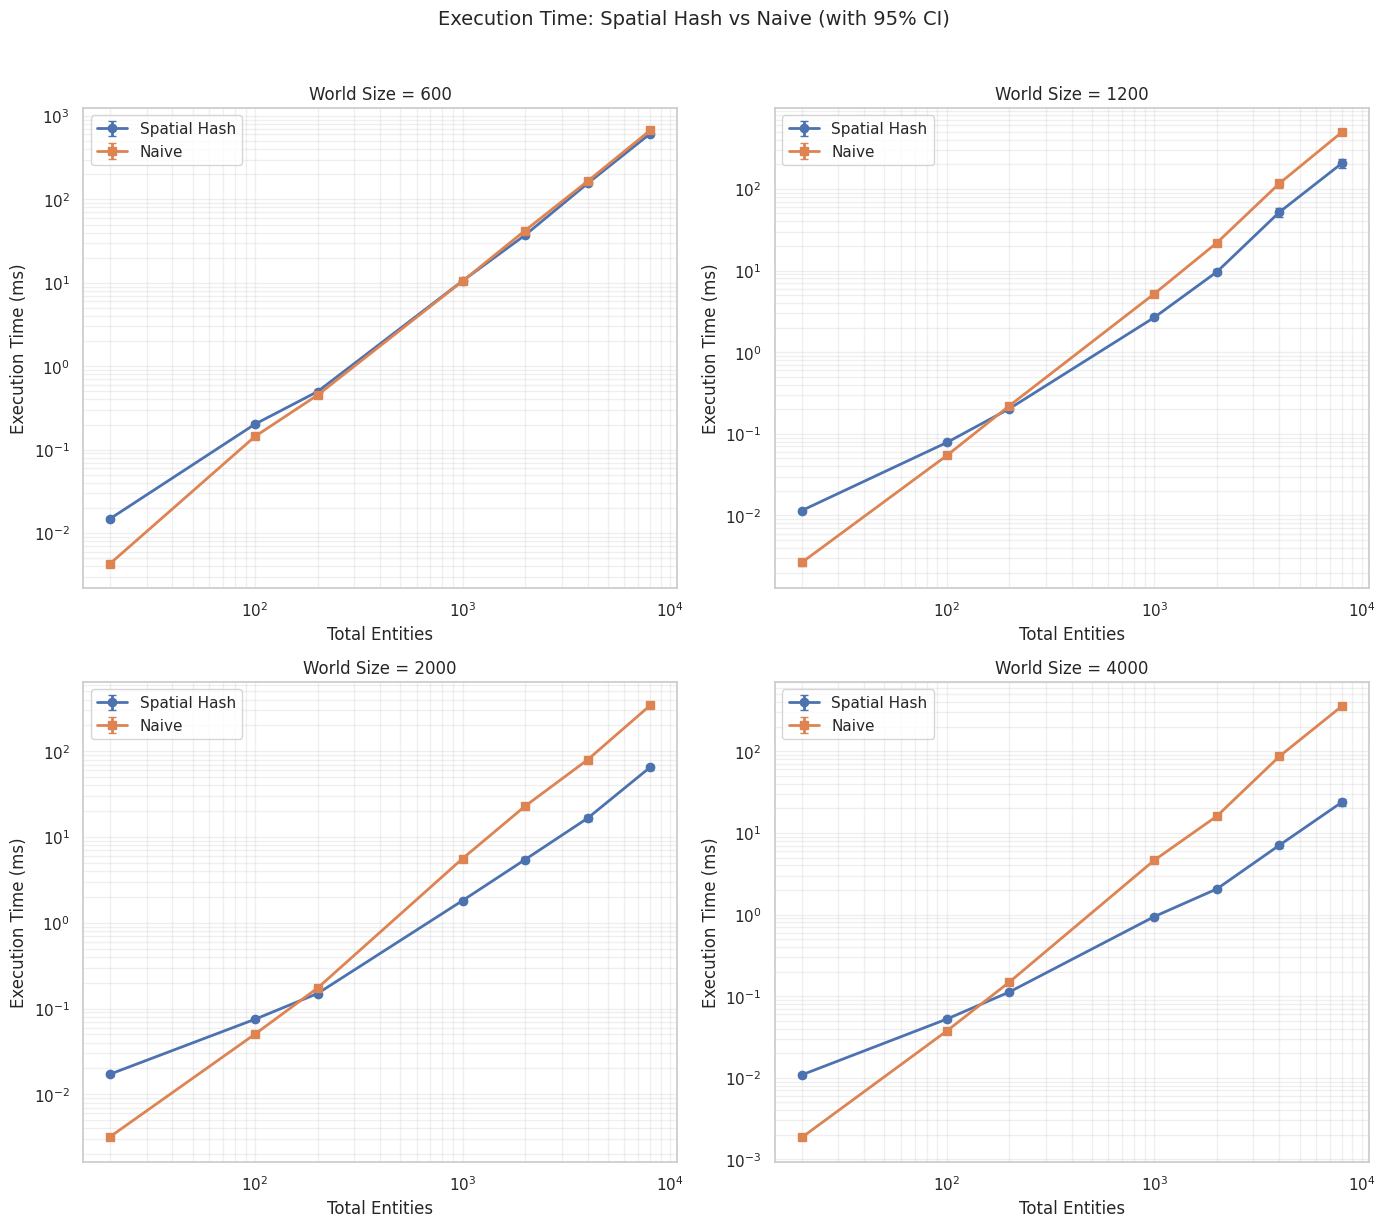

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

for i, world_size in enumerate(sorted(df_total['world_size'].unique())):
    ax = axes[i // 2, i % 2]
    subset = stats_df[(stats_df['world_size'] == world_size) & (stats_df['sense_type'] == 'predator')]
    
    ax.errorbar(subset['total_entities'], subset['sh_mean_ms'], 
                yerr=subset['sh_ci95'], marker='o', capsize=3, label='Spatial Hash', linewidth=2)
    ax.errorbar(subset['total_entities'], subset['naive_mean_ms'], 
                yerr=subset['naive_ci95'], marker='s', capsize=3, label='Naive', linewidth=2)
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Total Entities')
    ax.set_ylabel('Execution Time (ms)')
    ax.set_title(f'World Size = {world_size}')
    ax.legend()
    ax.grid(True, which='both', alpha=0.3)

plt.suptitle('Execution Time: Spatial Hash vs Naive (with 95% CI)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'execution_time_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

## 3. Speedup Factor vs Entity Count

Analyzing how speedup scales with entity count for different world sizes.

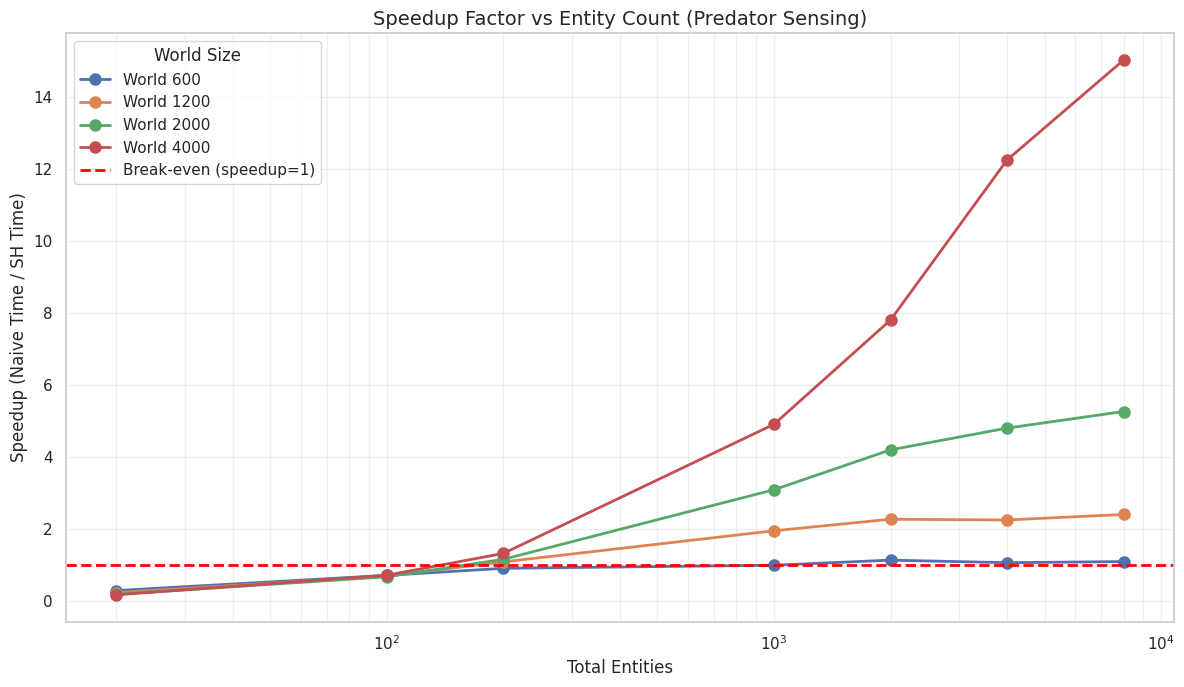

In [ ]:
fig, ax = plt.subplots(figsize=(12, 7))

pred_stats = stats_df[stats_df['sense_type'] == 'predator']
for world_size in sorted(pred_stats['world_size'].unique()):
    subset = pred_stats[pred_stats['world_size'] == world_size]
    ax.plot(subset['total_entities'], subset['speedup_mean'], 
            marker='o', linewidth=2, markersize=8, label=f'World {world_size}')

ax.axhline(y=1, color='red', linestyle='--', linewidth=2, label='Break-even (speedup=1)')
# ax.set_xscale('log')
ax.set_xlabel('Total Entities', fontsize=12)
ax.set_ylabel('Speedup (Naive Time / SH Time)', fontsize=12)
ax.set_title('Speedup Factor vs Entity Count (Predator Sensing)', fontsize=14)
ax.legend(title='World Size')
ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'speedup_vs_entities.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4. Build vs Query Time Breakdown

Analyzing the contribution of build and query phases to total execution time.

In [10]:
# Analyze build vs query breakdown for spatial hash
df_build = df[df['operation'] == 'build']
df_query = df[df['operation'] == 'query']

build_stats = df_build.groupby(['world_size', 'total_entities', 'sense_type']).agg({
    'sh_ms': ['mean', 'std'],
    'naive_ms': ['mean', 'std']
}).reset_index()
build_stats.columns = ['world_size', 'total_entities', 'sense_type', 
                       'sh_build_mean', 'sh_build_std', 'naive_build_mean', 'naive_build_std']

query_stats = df_query.groupby(['world_size', 'total_entities', 'sense_type']).agg({
    'sh_ms': ['mean', 'std'],
    'naive_ms': ['mean', 'std']
}).reset_index()
query_stats.columns = ['world_size', 'total_entities', 'sense_type', 
                       'sh_query_mean', 'sh_query_std', 'naive_query_mean', 'naive_query_std']

# Merge for comparison
breakdown = pd.merge(build_stats, query_stats, on=['world_size', 'total_entities', 'sense_type'])
breakdown['sh_total'] = breakdown['sh_build_mean'] + breakdown['sh_query_mean']
breakdown['build_fraction'] = breakdown['sh_build_mean'] / breakdown['sh_total'] * 100

print("Build vs Query Breakdown (Spatial Hash - Predator Sensing)")
print("=" * 70)
pred_breakdown = breakdown[breakdown['sense_type'] == 'predator'][
    ['world_size', 'total_entities', 'sh_build_mean', 'sh_query_mean', 'sh_total', 'build_fraction']
].sort_values(['world_size', 'total_entities'])
display(pred_breakdown.round(3))

Build vs Query Breakdown (Spatial Hash - Predator Sensing)


,world_size,total_entities,sh_build_mean,sh_query_mean,sh_total,build_fraction
0,600,20,0.003,0.011,0.015,22.404
2,600,100,0.022,0.180,0.203,11.095
4,600,200,0.033,0.464,0.497,6.611
6,600,1000,0.163,10.395,10.559,1.546
8,600,2000,0.316,36.987,37.303,0.848
10,600,4000,0.725,154.396,155.121,0.467
12,600,8000,1.181,610.710,611.891,0.193
14,1200,20,0.004,0.008,0.012,35.087
16,1200,100,0.019,0.060,0.078,23.613
18,1200,200,0.036,0.168,0.203,17.573


## 5. Performance Variability (Box Plots)

Analyzing run-to-run variability for different configurations.

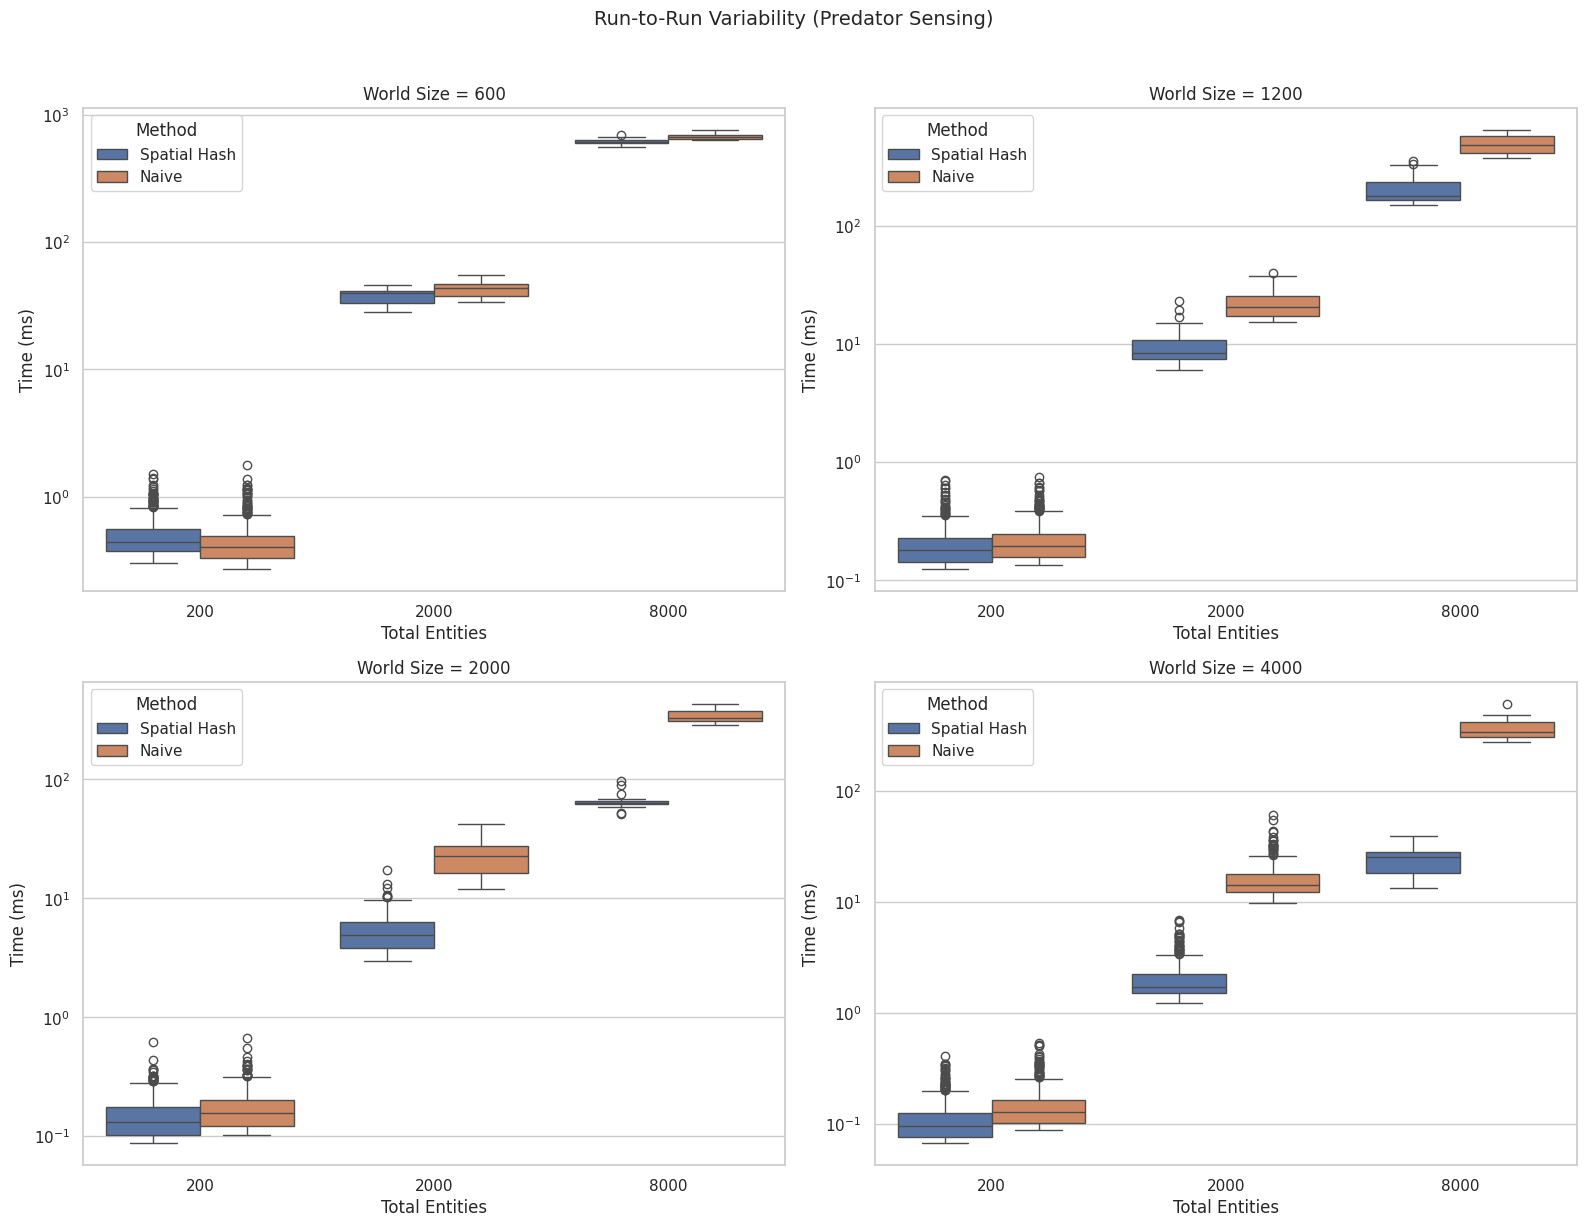

In [11]:
# Box plots for performance variability
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Select a few representative entity counts
entity_counts = [100, 1000, 4000]
df_boxplot = df_total[(df_total['total_entities'].isin([e*2 for e in entity_counts])) & 
                       (df_total['sense_type'] == 'predator')]

for i, world_size in enumerate([600, 1200, 2000, 4000]):
    ax = axes[i // 2, i % 2]
    subset = df_boxplot[df_boxplot['world_size'] == world_size]
    
    if len(subset) > 0:
        melted = subset.melt(id_vars=['total_entities', 'iteration'], 
                             value_vars=['sh_ms', 'naive_ms'],
                             var_name='Method', value_name='Time (ms)')
        melted['Method'] = melted['Method'].map({'sh_ms': 'Spatial Hash', 'naive_ms': 'Naive'})
        
        sns.boxplot(data=melted, x='total_entities', y='Time (ms)', hue='Method', ax=ax)
        ax.set_title(f'World Size = {world_size}')
        ax.set_xlabel('Total Entities')
        ax.set_yscale('log')

plt.suptitle('Run-to-Run Variability (Predator Sensing)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'variability_boxplot.png'), dpi=150, bbox_inches='tight')
plt.show()

## 6. Density Analysis

Examining how entity density (entities per unit area) affects performance.

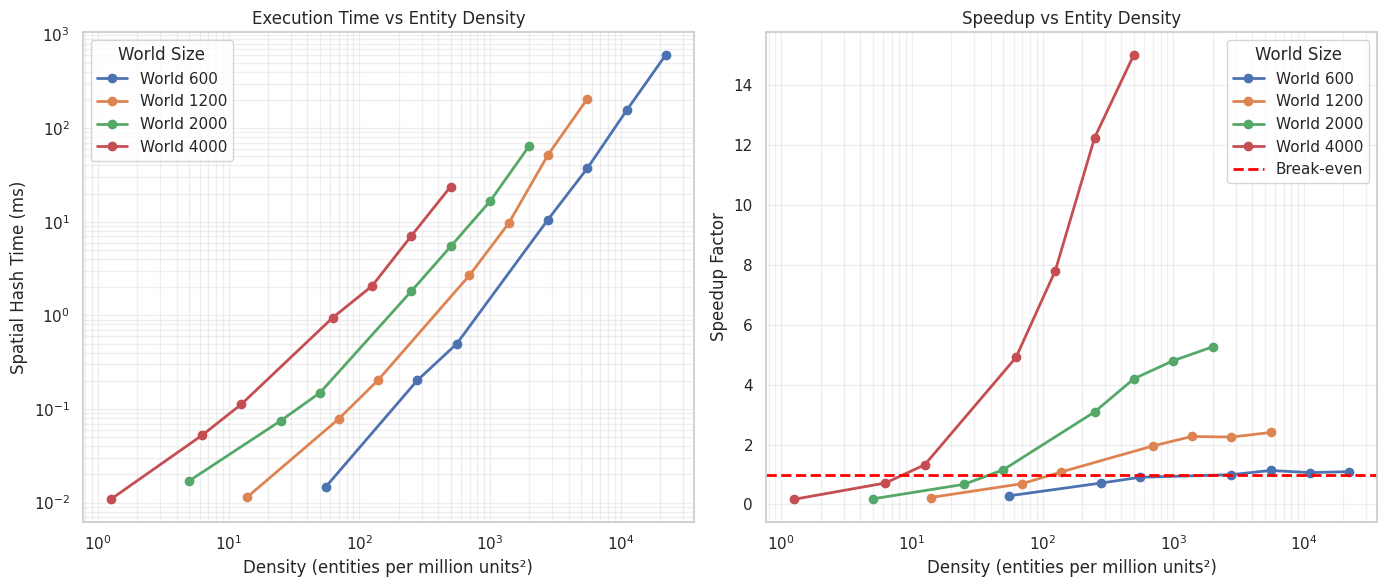

In [12]:
# Analyze performance vs density
stats_df['density'] = stats_df['total_entities'] / (stats_df['world_size'] ** 2)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Execution time vs density
ax = axes[0]
pred_stats = stats_df[stats_df['sense_type'] == 'predator']
for world_size in sorted(pred_stats['world_size'].unique()):
    subset = pred_stats[pred_stats['world_size'] == world_size]
    ax.plot(subset['density'] * 1e6, subset['sh_mean_ms'], 
            marker='o', linewidth=2, label=f'World {world_size}')

ax.set_xlabel('Density (entities per million units²)', fontsize=12)
ax.set_ylabel('Spatial Hash Time (ms)', fontsize=12)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_title('Execution Time vs Entity Density')
ax.legend(title='World Size')
ax.grid(True, which='both', alpha=0.3)

# Speedup vs density
ax = axes[1]
for world_size in sorted(pred_stats['world_size'].unique()):
    subset = pred_stats[pred_stats['world_size'] == world_size]
    ax.plot(subset['density'] * 1e6, subset['speedup_mean'], 
            marker='o', linewidth=2, label=f'World {world_size}')

ax.axhline(y=1, color='red', linestyle='--', linewidth=2, label='Break-even')
ax.set_xlabel('Density (entities per million units²)', fontsize=12)
ax.set_ylabel('Speedup Factor', fontsize=12)
ax.set_xscale('log')
ax.set_title('Speedup vs Entity Density')
ax.legend(title='World Size')
ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'density_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

## 7. Algorithmic Complexity Analysis

Estimating the time complexity of both algorithms by fitting power laws.

Algorithmic Complexity Analysis
Exponent values: ~1 indicates O(N), ~2 indicates O(N²)



Algorithmic Complexity Analysis
Exponent values: ~1 indicates O(N), ~2 indicates O(N²)



,world_size,sh_exponent,sh_r_squared,naive_exponent,naive_r_squared
0,600,1.780,0.997,1.973,0.999
1,1200,1.645,0.986,2.027,0.999
2,2000,1.395,0.985,1.963,0.998
3,4000,1.278,0.990,2.044,0.999


Algorithmic Complexity Analysis
Exponent values: ~1 indicates O(N), ~2 indicates O(N²)



,world_size,sh_exponent,sh_r_squared,naive_exponent,naive_r_squared
0,600,1.780,0.997,1.973,0.999
1,1200,1.645,0.986,2.027,0.999
2,2000,1.395,0.985,1.963,0.998
3,4000,1.278,0.990,2.044,0.999


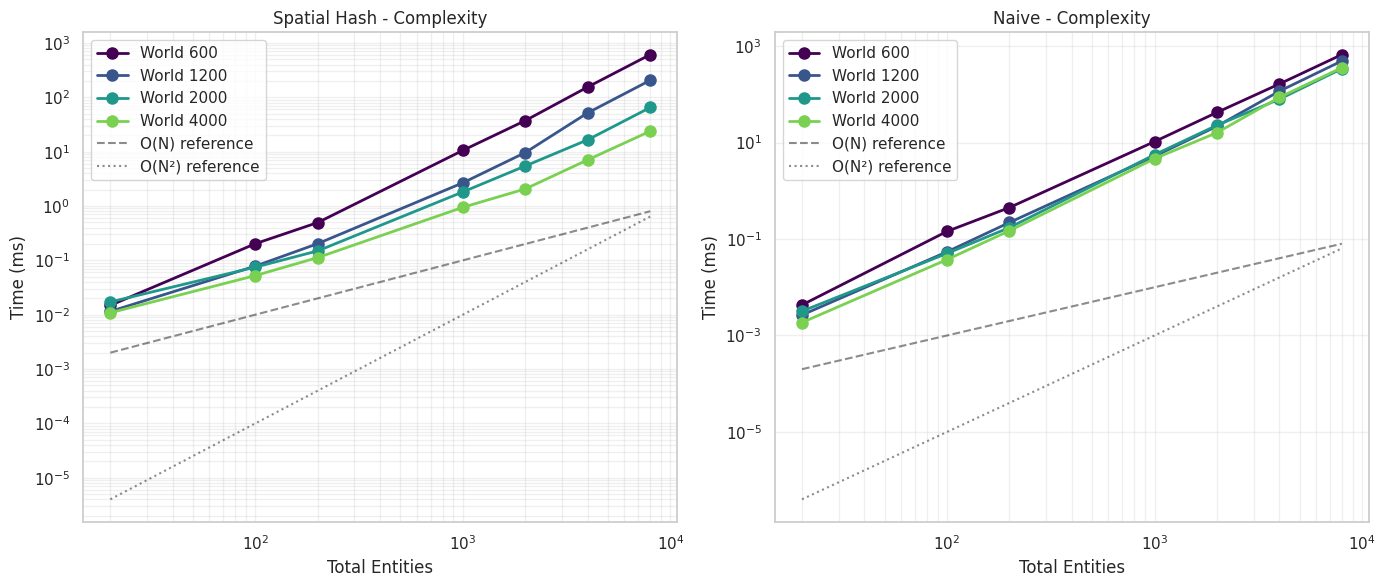

In [13]:
# Fit power laws to estimate complexity
# Time = c * N^k => log(Time) = log(c) + k * log(N)

complexity_results = []

for world_size in sorted(stats_df['world_size'].unique()):
    subset = stats_df[(stats_df['world_size'] == world_size) & (stats_df['sense_type'] == 'predator')]
    
    x = np.log10(subset['total_entities'].values)
    
    # Fit for Spatial Hash
    y_sh = np.log10(subset['sh_mean_ms'].values)
    slope_sh, intercept_sh, r_sh, p_sh, se_sh = stats.linregress(x, y_sh)
    
    # Fit for Naive
    y_naive = np.log10(subset['naive_mean_ms'].values)
    slope_naive, intercept_naive, r_naive, p_naive, se_naive = stats.linregress(x, y_naive)
    
    complexity_results.append({
        'world_size': world_size,
        'sh_exponent': slope_sh,
        'sh_r_squared': r_sh**2,
        'naive_exponent': slope_naive,
        'naive_r_squared': r_naive**2
    })

complexity_df = pd.DataFrame(complexity_results)
print("Algorithmic Complexity Analysis")
print("=" * 70)
print("Exponent values: ~1 indicates O(N), ~2 indicates O(N²)")
print()
display(complexity_df.round(3))

# Visualize with fits
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = plt.cm.viridis(np.linspace(0, 0.8, len(stats_df['world_size'].unique())))

ax = axes[0]
for i, world_size in enumerate(sorted(stats_df['world_size'].unique())):
    subset = stats_df[(stats_df['world_size'] == world_size) & (stats_df['sense_type'] == 'predator')]
    ax.loglog(subset['total_entities'], subset['sh_mean_ms'], 'o-', 
              color=colors[i], label=f'World {world_size}', linewidth=2, markersize=8)

# Add reference lines
x_ref = np.array([20, 8000])
ax.loglog(x_ref, 0.01 * (x_ref/100), 'k--', alpha=0.5, label='O(N) reference')
ax.loglog(x_ref, 0.0001 * (x_ref/100)**2, 'k:', alpha=0.5, label='O(N²) reference')
ax.set_xlabel('Total Entities', fontsize=12)
ax.set_ylabel('Time (ms)', fontsize=12)
ax.set_title('Spatial Hash - Complexity')
ax.legend()
ax.grid(True, which='both', alpha=0.3)

ax = axes[1]
for i, world_size in enumerate(sorted(stats_df['world_size'].unique())):
    subset = stats_df[(stats_df['world_size'] == world_size) & (stats_df['sense_type'] == 'predator')]
    ax.loglog(subset['total_entities'], subset['naive_mean_ms'], 'o-', 
              color=colors[i], label=f'World {world_size}', linewidth=2, markersize=8)

ax.loglog(x_ref, 0.001 * (x_ref/100), 'k--', alpha=0.5, label='O(N) reference')
ax.loglog(x_ref, 0.00001 * (x_ref/100)**2, 'k:', alpha=0.5, label='O(N²) reference')
ax.set_xlabel('Total Entities', fontsize=12)
ax.set_ylabel('Time (ms)', fontsize=12)
ax.set_title('Naive - Complexity')
ax.legend()
ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'complexity_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

## 8. Comprehensive Statistical Summary Table

Detailed summary including coefficient of variation (CV) for stability analysis.

In [14]:
# Comprehensive statistics table
stats_df['sh_cv'] = (stats_df['sh_std_ms'] / stats_df['sh_mean_ms'] * 100)  # Coefficient of variation
stats_df['naive_cv'] = (stats_df['naive_std_ms'] / stats_df['naive_mean_ms'] * 100)

# Create a clean summary table
summary_table = stats_df[stats_df['sense_type'] == 'predator'][[
    'world_size', 'total_entities', 'n_samples',
    'sh_mean_ms', 'sh_std_ms', 'sh_cv', 'sh_min_ms', 'sh_max_ms',
    'naive_mean_ms', 'naive_std_ms', 'naive_cv', 'naive_min_ms', 'naive_max_ms',
    'speedup_mean', 'speedup_std'
]].sort_values(['world_size', 'total_entities'])

print("Comprehensive Statistical Summary (Predator Sensing - Total Phase)")
print("=" * 100)
print("CV = Coefficient of Variation (std/mean × 100), lower is more stable")
print()

# Format and display
summary_display = summary_table.copy()
summary_display = summary_display.rename(columns={
    'world_size': 'World',
    'total_entities': 'Entities',
    'n_samples': 'N',
    'sh_mean_ms': 'SH Mean',
    'sh_std_ms': 'SH Std',
    'sh_cv': 'SH CV%',
    'sh_min_ms': 'SH Min',
    'sh_max_ms': 'SH Max',
    'naive_mean_ms': 'Naive Mean',
    'naive_std_ms': 'Naive Std',
    'naive_cv': 'Naive CV%',
    'naive_min_ms': 'Naive Min',
    'naive_max_ms': 'Naive Max',
    'speedup_mean': 'Speedup',
    'speedup_std': 'Speed Std'
})

display(summary_display.round(3))

Comprehensive Statistical Summary (Predator Sensing - Total Phase)
CV = Coefficient of Variation (std/mean × 100), lower is more stable



,World,Entities,N,SH Mean,SH Std,SH CV%,SH Min,SH Max,Naive Mean,Naive Std,Naive CV%,Naive Min,Naive Max,Speedup,Speed Std
0,600,20,500.0,0.015,0.009,61.248,0.009,0.067,0.004,0.003,62.203,0.002,0.024,0.289,0.100
2,600,100,500.0,0.203,0.136,67.264,0.094,0.844,0.144,0.097,67.224,0.068,0.594,0.712,0.177
4,600,200,500.0,0.497,0.184,37.150,0.305,1.523,0.451,0.185,41.125,0.270,1.786,0.908,0.197
6,600,1000,72.0,10.559,2.820,26.712,7.042,19.483,10.490,2.591,24.695,6.861,17.026,0.994,0.257
8,600,2000,25.0,37.303,5.039,13.509,28.311,46.300,42.349,6.015,14.203,33.706,54.689,1.135,0.248
10,600,4000,25.0,155.122,19.777,12.750,134.346,225.594,164.994,10.572,6.407,150.945,187.121,1.064,0.109
12,600,8000,25.0,611.891,30.359,4.962,553.778,686.445,670.325,36.615,5.462,627.504,758.454,1.095,0.082
14,1200,20,500.0,0.011,0.007,58.844,0.007,0.070,0.003,0.003,100.642,0.001,0.026,0.231,0.146
16,1200,100,500.0,0.078,0.035,45.276,0.048,0.257,0.054,0.027,49.926,0.033,0.372,0.693,0.155
18,1200,200,500.0,0.203,0.085,41.726,0.124,0.706,0.221,0.090,40.962,0.134,0.747,1.086,0.278


## 9. Key Findings Summary

In [15]:
# Generate key findings
print("=" * 80)
print("KEY FINDINGS SUMMARY")
print("=" * 80)

# Find crossover points (where speedup > 1)
crossover_analysis = stats_df[stats_df['sense_type'] == 'predator'].copy()

print("\n1. BREAK-EVEN ANALYSIS")
print("-" * 40)
for world_size in sorted(crossover_analysis['world_size'].unique()):
    subset = crossover_analysis[crossover_analysis['world_size'] == world_size].sort_values('total_entities')
    beneficial = subset[subset['speedup_mean'] >= 1]
    if len(beneficial) > 0:
        min_entities = beneficial['total_entities'].min()
        print(f"   World {world_size}: Spatial Hash faster at >= {int(min_entities)} entities")
    else:
        print(f"   World {world_size}: Spatial Hash slower for all tested entity counts")

print("\n2. MAXIMUM SPEEDUP ACHIEVED")
print("-" * 40)
max_speedup_row = stats_df[stats_df['sense_type'] == 'predator'].loc[
    stats_df[stats_df['sense_type'] == 'predator']['speedup_mean'].idxmax()]
print(f"   {max_speedup_row['speedup_mean']:.2f}x at World={int(max_speedup_row['world_size'])}, "
      f"Entities={int(max_speedup_row['total_entities'])}")

print("\n3. COMPLEXITY ANALYSIS")
print("-" * 40)
avg_sh_exp = complexity_df['sh_exponent'].mean()
avg_naive_exp = complexity_df['naive_exponent'].mean()
print(f"   Spatial Hash: Average exponent = {avg_sh_exp:.2f} (closer to 1 = O(N))")
print(f"   Naive:        Average exponent = {avg_naive_exp:.2f} (closer to 2 = O(N²))")

print("\n4. PERFORMANCE STABILITY")
print("-" * 40)
avg_sh_cv = stats_df[stats_df['sense_type'] == 'predator']['sh_cv'].mean()
avg_naive_cv = stats_df[stats_df['sense_type'] == 'predator']['naive_cv'].mean()
print(f"   Spatial Hash: Average CV = {avg_sh_cv:.1f}%")
print(f"   Naive:        Average CV = {avg_naive_cv:.1f}%")
print(f"   Lower CV indicates more consistent performance")

print("\n5. WORST CASE SCENARIOS")
print("-" * 40)
min_speedup_row = stats_df[stats_df['sense_type'] == 'predator'].loc[
    stats_df[stats_df['sense_type'] == 'predator']['speedup_mean'].idxmin()]
print(f"   Minimum speedup: {min_speedup_row['speedup_mean']:.2f}x at World={int(min_speedup_row['world_size'])}, "
      f"Entities={int(min_speedup_row['total_entities'])}")

print("\n" + "=" * 80)

KEY FINDINGS SUMMARY

1. BREAK-EVEN ANALYSIS
----------------------------------------
   World 600: Spatial Hash faster at >= 2000 entities
   World 1200: Spatial Hash faster at >= 200 entities
   World 2000: Spatial Hash faster at >= 200 entities
   World 4000: Spatial Hash faster at >= 200 entities

2. MAXIMUM SPEEDUP ACHIEVED
----------------------------------------
   15.03x at World=4000, Entities=8000

3. COMPLEXITY ANALYSIS
----------------------------------------
   Spatial Hash: Average exponent = 1.52 (closer to 1 = O(N))
   Naive:        Average exponent = 2.00 (closer to 2 = O(N²))

4. PERFORMANCE STABILITY
----------------------------------------
   Spatial Hash: Average CV = 39.7%
   Naive:        Average CV = 38.5%
   Lower CV indicates more consistent performance

5. WORST CASE SCENARIOS
----------------------------------------
   Minimum speedup: 0.17x at World=4000, Entities=20



## 10. Save Summary Tables to CSV